In [ ]:
from itertools import combinations

# ---------------- TRANSACTIONS ----------------
transactions = [
    ['Milk', 'Bread', 'Butter'],
    ['Bread', 'Eggs'],
    ['Milk', 'Bread', 'Eggs'],
    ['Milk', 'Butter'],
    ['Bread', 'Butter'],
    ['Milk', 'Bread', 'Butter', 'Eggs']
]

N = len(transactions)

# ---------------- SUPPORT FUNCTION ----------------
def support(itemset, transactions):
    count = 0
    for t in transactions:
        if set(itemset).issubset(t):
            count += 1
    return count / len(transactions)

# ---------------- GENERATE CANDIDATES ----------------
def generate_candidates(items, k):
    return list(combinations(items, k))

# ---------------- APRIORI (GENERALIZED) ----------------
def apriori(transactions, min_support):
    all_items = sorted(set(item for t in transactions for item in t))
    frequent_itemsets = {}

    k = 1
    current_items = all_items

    while True:
        candidates = generate_candidates(current_items, k)

        frequent_k = []
        print(f"\nCandidate {k}-itemsets:", candidates)

        for itemset in candidates:
            sup = support(itemset, transactions)
            if sup >= min_support:
                frequent_k.append(itemset)
                frequent_itemsets[itemset] = sup

        if not frequent_k:
            break

        print(f"\nFrequent {k}-itemsets:")
        for f in frequent_k:
            print(f, "Support:", round(frequent_itemsets[f], 2))

        # Prepare items for next iteration
        current_items = sorted(set(item for itemset in frequent_k for item in itemset))
        k += 1

    return frequent_itemsets

# ---------------- ASSOCIATION RULES ----------------
def generate_rules(frequent_itemsets, min_confidence):
    print("\n============================")
    print("Association Rules Generated")
    print("============================")

    for itemset in frequent_itemsets:
        if len(itemset) < 2:
            continue

        itemset_support = frequent_itemsets[itemset]

        # Generate rules: A -> B
        for i in range(1, len(itemset)):
            for A in combinations(itemset, i):
                B = tuple(set(itemset) - set(A))

                sup_A = frequent_itemsets.get(tuple(sorted(A)), support(A, transactions))
                sup_B = frequent_itemsets.get(tuple(sorted(B)), support(B, transactions))

                confidence = itemset_support / sup_A
                lift = confidence / sup_B

                if confidence >= min_confidence:
                    print(f"{A} -> {B} | Support={itemset_support:.2f}, "
                          f"Confidence={confidence:.2f}, Lift={lift:.2f}")

# ---------------- MAIN PROGRAM ----------------
min_support = 0.4
min_confidence = 0.6

print("Transactions:")
for t in transactions:
    print(t)

# Run Apriori
frequent_itemsets = apriori(transactions, min_support)

print("\n============================")
print("All Frequent Itemsets Found")
print("============================")
for itemset, sup in frequent_itemsets.items():
    print(itemset, "Support:", round(sup, 2))

# Generate association rules
generate_rules(frequent_itemsets, min_confidence)

Transactions:
['Milk', 'Bread', 'Butter']
['Bread', 'Eggs']
['Milk', 'Bread', 'Eggs']
['Milk', 'Butter']
['Bread', 'Butter']
['Milk', 'Bread', 'Butter', 'Eggs']

Candidate 1-itemsets: [('Bread',), ('Butter',), ('Eggs',), ('Milk',)]

Frequent 1-itemsets:
('Bread',) Support: 0.83
('Butter',) Support: 0.67
('Eggs',) Support: 0.5
('Milk',) Support: 0.67

Candidate 2-itemsets: [('Bread', 'Butter'), ('Bread', 'Eggs'), ('Bread', 'Milk'), ('Butter', 'Eggs'), ('Butter', 'Milk'), ('Eggs', 'Milk')]

Frequent 2-itemsets:
('Bread', 'Butter') Support: 0.5
('Bread', 'Eggs') Support: 0.5
('Bread', 'Milk') Support: 0.5
('Butter', 'Milk') Support: 0.5

Candidate 3-itemsets: [('Bread', 'Butter', 'Eggs'), ('Bread', 'Butter', 'Milk'), ('Bread', 'Eggs', 'Milk'), ('Butter', 'Eggs', 'Milk')]

All Frequent Itemsets Found
('Bread',) Support: 0.83
('Butter',) Support: 0.67
('Eggs',) Support: 0.5
('Milk',) Support: 0.67
('Bread', 'Butter') Support: 0.5
('Bread', 'Eggs') Support: 0.5
('Bread', 'Milk') Support: 0.5

In [ ]:
# ================================
# Import Required Libraries
# ================================
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score


# ======================================================
# Question B: Dataset Exploration
# Operation: Load dataset and explore its structure
# ======================================================

ratings = pd.read_csv("ratings.csv")

print("First 5 rows of dataset:")
print(ratings.head())

print("\nDataset Information:")
print(ratings.info())

print("\nStatistical Summary:")
print(ratings.describe())


# ======================================================
# Operation: Create User-Item Interaction Matrix
# ======================================================

user_item_matrix = ratings.pivot_table(index='userId',
                                       columns='movieId',
                                       values='rating')

user_item_matrix = user_item_matrix.fillna(0)

print("\nUser Item Matrix:")
print(user_item_matrix.head())


# ======================================================
# Question C: User-Based Collaborative Filtering
# Operation: Calculate similarity between users
# ======================================================

user_similarity = cosine_similarity(user_item_matrix)

user_similarity_df = pd.DataFrame(user_similarity,
                                  index=user_item_matrix.index,
                                  columns=user_item_matrix.index)

print("\nUser Similarity Matrix:")
print(user_similarity_df.head())


# ======================================================
# Operation: Recommend items based on similar users
# ======================================================

def recommend_movies_user(user_id, n=5):

    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:6]

    similar_users_movies = user_item_matrix.loc[similar_users.index]

    recommendation_scores = similar_users_movies.mean().sort_values(ascending=False)

    return recommendation_scores.head(n)


print("\nUser Based Recommendations for User 1:")
print(recommend_movies_user(1))


# ======================================================
# Question D: Item-Based Collaborative Filtering
# Operation: Calculate similarity between items
# ======================================================

item_matrix = user_item_matrix.T

item_similarity = cosine_similarity(item_matrix)

item_similarity_df = pd.DataFrame(item_similarity,
                                  index=item_matrix.index,
                                  columns=item_matrix.index)

print("\nItem Similarity Matrix:")
print(item_similarity_df.head())


# ======================================================
# Operation: Recommend similar items
# ======================================================

def recommend_movies_item(movie_id, n=5):

    similar_movies = item_similarity_df[movie_id].sort_values(ascending=False)[1:n+1]

    return similar_movies


print("\nItem Based Recommendations for Movie 1:")
print(recommend_movies_item(1))


# ======================================================
# Question E: Hybrid Recommender System
# Operation: Combine User-Based and Item-Based approaches
# ======================================================

hybrid_similarity = (user_similarity + item_similarity[:user_similarity.shape[0], :user_similarity.shape[0]]) / 2

print("\nHybrid Similarity Matrix Created")


# ======================================================
# Question F: Evaluation Metrics
# Operation: Calculate Precision, Recall and F1 Score
# ======================================================

threshold = 3.5

ratings['relevant'] = ratings['rating'].apply(lambda x: 1 if x >= threshold else 0)

y_true = ratings['relevant']
y_pred = (ratings['rating'] >= threshold).astype(int)

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\nEvaluation Results:")
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


# ======================================================
# Final Output
# ======================================================

print("\nFinal Recommendation Example")
print("Recommended Movies for User 1:")
print(recommend_movies_user(1))

First 5 rows of dataset:
   userId  movieId  rating   timestamp
0       1        6       5  1773685416
1       1        7       4  1773685416
2       1        3       5  1773685416
3       1       10       1  1773685416
4       1        9       4  1773685416

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   userId     60 non-null     int64
 1   movieId    60 non-null     int64
 2   rating     60 non-null     int64
 3   timestamp  60 non-null     int64
dtypes: int64(4)
memory usage: 2.0 KB
None

Statistical Summary:
         userId    movieId     rating     timestamp
count  60.00000  60.000000  60.000000  6.000000e+01
mean    5.50000   5.783333   3.116667  1.773685e+09
std     2.89652   2.923265   1.354111  0.000000e+00
min     1.00000   1.000000   1.000000  1.773685e+09
25%     3.00000   3.000000   2.000000  1.773685e+09
50%     5.50

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Training Finished


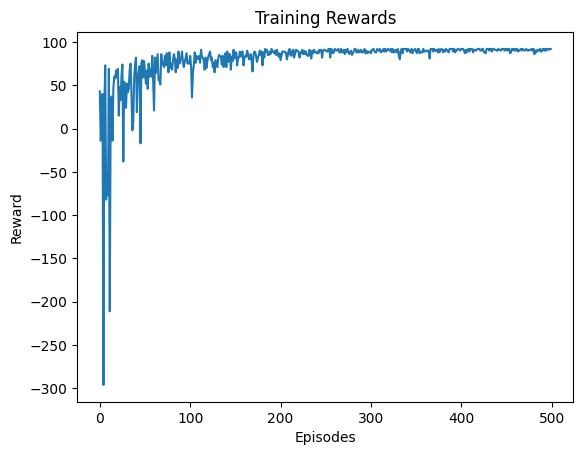


Agent Path:
[[9 0 0 1 0]
 [1 1 0 1 0]
 [0 0 0 0 0]
 [0 1 1 1 0]
 [0 0 0 2 0]]
[[0 9 0 1 0]
 [1 1 0 1 0]
 [0 0 0 0 0]
 [0 1 1 1 0]
 [0 0 0 2 0]]
[[0 0 9 1 0]
 [1 1 0 1 0]
 [0 0 0 0 0]
 [0 1 1 1 0]
 [0 0 0 2 0]]
[[0 0 0 1 0]
 [1 1 9 1 0]
 [0 0 0 0 0]
 [0 1 1 1 0]
 [0 0 0 2 0]]
[[0 0 0 1 0]
 [1 1 0 1 0]
 [0 0 9 0 0]
 [0 1 1 1 0]
 [0 0 0 2 0]]
[[0 0 0 1 0]
 [1 1 0 1 0]
 [0 0 0 9 0]
 [0 1 1 1 0]
 [0 0 0 2 0]]
[[0 0 0 1 0]
 [1 1 0 1 0]
 [0 0 0 0 9]
 [0 1 1 1 0]
 [0 0 0 2 0]]
[[0 0 0 1 0]
 [1 1 0 1 0]
 [0 0 0 0 0]
 [0 1 1 1 9]
 [0 0 0 2 0]]
[[0 0 0 1 0]
 [1 1 0 1 0]
 [0 0 0 0 0]
 [0 1 1 1 0]
 [0 0 0 2 9]]
[[0 0 0 1 0]
 [1 1 0 1 0]
 [0 0 0 0 0]
 [0 1 1 1 0]
 [0 0 0 9 0]]
Goal Reached!


In [ ]:
# ======================================================
# Import Required Libraries
# ======================================================

import numpy as np
import gym
from gym import spaces
import random
import matplotlib.pyplot as plt


# ======================================================
# Question A: Introduction to OpenAI Gym
# Operation: Define a custom maze environment
# ======================================================

class MazeEnv(gym.Env):

    def __init__(self):

        super(MazeEnv, self).__init__()

        # Maze layout
        # 0 = empty path
        # 1 = wall
        # 2 = goal

        self.maze = np.array([
            [0,0,0,1,0],
            [1,1,0,1,0],
            [0,0,0,0,0],
            [0,1,1,1,0],
            [0,0,0,2,0]
        ])

        self.start_pos = (0,0)
        self.agent_pos = self.start_pos

        self.goal_pos = (4,3)

        # Action space
        # 0 = up
        # 1 = down
        # 2 = left
        # 3 = right
        self.action_space = spaces.Discrete(4)

        # Observation space
        self.observation_space = spaces.Box(low=0, high=4, shape=(2,), dtype=np.int32)


# ======================================================
# Question B: Environment Functions
# Operation: Reset and render the environment
# ======================================================

    def reset(self):

        self.agent_pos = self.start_pos
        return np.array(self.agent_pos)


    def render(self):

        maze_copy = self.maze.copy()

        x,y = self.agent_pos
        maze_copy[x,y] = 9

        print(maze_copy)


# ======================================================
# Question C: Defining Actions and Observations
# Operation: Move the agent inside the maze
# ======================================================

    def step(self, action):

        x,y = self.agent_pos

        if action == 0:  # up
            x -= 1
        elif action == 1: # down
            x += 1
        elif action == 2: # left
            y -= 1
        elif action == 3: # right
            y += 1

        # Boundary check
        if x < 0 or x >= 5 or y < 0 or y >= 5:
            x,y = self.agent_pos

        # Wall check
        if self.maze[x,y] == 1:
            x,y = self.agent_pos

        self.agent_pos = (x,y)

        reward = -1
        done = False

        if self.agent_pos == self.goal_pos:
            reward = 100
            done = True

        return np.array(self.agent_pos), reward, done, {}


# ======================================================
# Question D: Implementing Q-Learning
# Operation: Initialize Q-table and parameters
# ======================================================

env = MazeEnv()

state_size = 25
action_size = env.action_space.n

q_table = np.zeros((state_size, action_size))

learning_rate = 0.1
gamma = 0.9
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.01

episodes = 500

rewards_list = []


# ======================================================
# Operation: Convert state position to index
# ======================================================

def state_to_index(state):
    return state[0]*5 + state[1]


# ======================================================
# Question E: Training the Agent
# Operation: Train using Q-learning algorithm
# ======================================================

for episode in range(episodes):

    state = env.reset()
    state_index = state_to_index(state)

    total_reward = 0

    done = False

    while not done:

        if random.uniform(0,1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state_index])

        next_state, reward, done, _ = env.step(action)

        next_state_index = state_to_index(next_state)

        q_table[state_index, action] = q_table[state_index, action] + learning_rate * (
            reward + gamma * np.max(q_table[next_state_index]) - q_table[state_index, action]
        )

        state_index = next_state_index
        total_reward += reward

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    rewards_list.append(total_reward)


print("Training Finished")


# ======================================================
# Operation: Plot learning progress
# ======================================================

plt.plot(rewards_list)
plt.title("Training Rewards")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.show()


# ======================================================
# Question F: Evaluation and Testing
# Operation: Test trained agent
# ======================================================

state = env.reset()

done = False

print("\nAgent Path:")

while not done:

    env.render()

    state_index = state_to_index(state)

    action = np.argmax(q_table[state_index])

    state, reward, done, _ = env.step(action)

env.render()

print("Goal Reached!")

In [ ]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import numpy as np
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.manifold import TSNE
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC

# ============================================
# LOAD DATASET (WINE DATASET)
# ============================================

wine = load_wine()
X = wine.data
y = wine.target

model = SVC()

# ============================================
# CASE 1 : REDUCE TO 2 FEATURES
# ============================================

print("\n--- CASE 1 : 2 FEATURES ---")

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
score_pca = cross_val_score(model, X_pca, y, cv=5)
print("PCA Accuracy:", score_pca.mean())

# LDA
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X, y)
score_lda = cross_val_score(model, X_lda, y, cv=5)
print("LDA Accuracy:", score_lda.mean())

# TSNE
tsne = TSNE(n_components=2, random_state=0)
X_tsne = tsne.fit_transform(X)
score_tsne = cross_val_score(model, X_tsne, y, cv=5)
print("TSNE Accuracy:", score_tsne.mean())

# SVD
svd = TruncatedSVD(n_components=2)
X_svd = svd.fit_transform(X)
score_svd = cross_val_score(model, X_svd, y, cv=5)
print("SVD Accuracy:", score_svd.mean())


# ============================================
# CASE 2 : REDUCE TO 3 FEATURES
# ============================================

print("\n--- CASE 2 : 3 FEATURES ---")

# PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)
score_pca = cross_val_score(model, X_pca, y, cv=5)
print("PCA Accuracy:", score_pca.mean())

# LDA (maximum components = classes-1 = 2)
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X, y)
score_lda = cross_val_score(model, X_lda, y, cv=5)
print("LDA Accuracy:", score_lda.mean())

# TSNE
tsne = TSNE(n_components=3, random_state=0)
X_tsne = tsne.fit_transform(X)
score_tsne = cross_val_score(model, X_tsne, y, cv=5)
print("TSNE Accuracy:", score_tsne.mean())

# SVD
svd = TruncatedSVD(n_components=3)
X_svd = svd.fit_transform(X)
score_svd = cross_val_score(model, X_svd, y, cv=5)
print("SVD Accuracy:", score_svd.mean())


--- CASE 1 : 2 FEATURES ---
PCA Accuracy: 0.703015873015873
LDA Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


TSNE Accuracy: 0.7028571428571428
SVD Accuracy: 0.6917460317460317

--- CASE 2 : 3 FEATURES ---
PCA Accuracy: 0.703015873015873
LDA Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


TSNE Accuracy: 0.7028571428571428
SVD Accuracy: 0.6804761904761905


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 31.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 24.9 MB/s eta 0:00:00
Silhouette Scores:
K-Means: 0.551
K-Medoids: 0.555
Fuzzy C-Means: 0.550


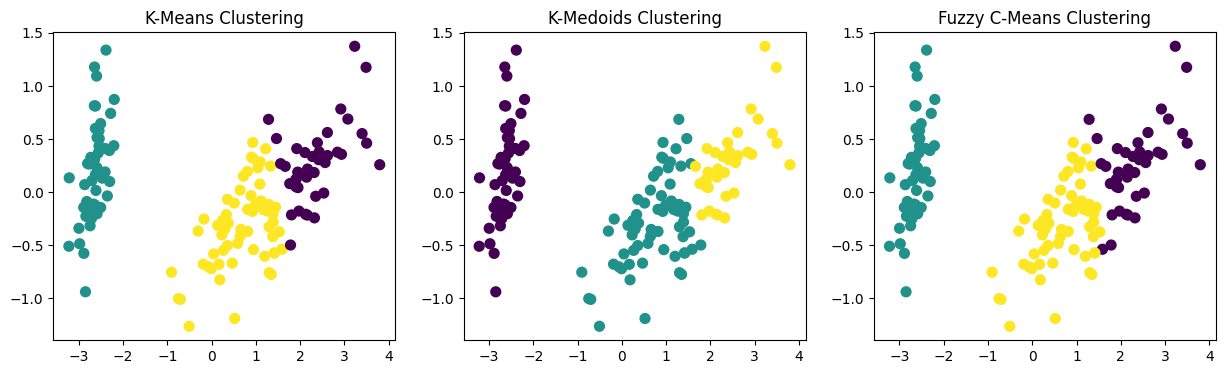

In [ ]:
# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Install pyclustering and scikit-fuzzy if not already installed
!pip install -q pyclustering scikit-fuzzy

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# K-Medoids via pyclustering
from pyclustering.cluster.kmedoids import kmedoids

# Fuzzy C-Means
import skfuzzy as fuzz

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
n_clusters = 3

# ------------------- K-Means -------------------
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels_kmeans = kmeans.fit_predict(X)
silhouette_kmeans = silhouette_score(X, labels_kmeans)

# ------------------- K-Medoids -------------------
# Initial medoid indices
initial_medoids = [0, 50, 100]
kmedoids_instance = kmedoids(X, initial_medoids)
kmedoids_instance.process()
clusters = kmedoids_instance.get_clusters()

# Convert cluster lists to flat label array
labels_kmedoids = np.zeros(X.shape[0])
for cluster_id, cluster_points in enumerate(clusters):
    for idx in cluster_points:
        labels_kmedoids[idx] = cluster_id
silhouette_kmedoids = silhouette_score(X, labels_kmedoids)

# ------------------- Fuzzy C-Means -------------------
X_T = X.T  # skfuzzy expects features x samples
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_T, c=n_clusters, m=2, error=0.005, maxiter=1000
)
labels_fcm = np.argmax(u, axis=0)
silhouette_fcm = silhouette_score(X, labels_fcm)

# ------------------- Print Results -------------------
print("Silhouette Scores:")
print(f"K-Means: {silhouette_kmeans:.3f}")
print(f"K-Medoids: {silhouette_kmedoids:.3f}")
print(f"Fuzzy C-Means: {silhouette_fcm:.3f}")

# ------------------- Optional 2D Visualization -------------------
X_2D = PCA(n_components=2).fit_transform(X)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.scatter(X_2D[:,0], X_2D[:,1], c=labels_kmeans, cmap='viridis', s=50)
plt.title('K-Means Clustering')

plt.subplot(1,3,2)
plt.scatter(X_2D[:,0], X_2D[:,1], c=labels_kmedoids, cmap='viridis', s=50)
plt.title('K-Medoids Clustering')

plt.subplot(1,3,3)
plt.scatter(X_2D[:,0], X_2D[:,1], c=labels_fcm, cmap='viridis', s=50)
plt.title('Fuzzy C-Means Clustering')

plt.show()

In [ ]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import numpy as np
import pandas as pd

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

# Ensemble methods
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, StackingClassifier


# ============================================
# LOAD DATASET
# ============================================

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# ============================================
# DEFINE CLASSIFIERS
# ============================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier()
}

results = {}

# ============================================
# EVALUATE ALL CLASSIFIERS
# ============================================

print("Classifier Performance:\n")

for name, model in models.items():

    scores = cross_val_score(model, X, y, cv=5)

    results[name] = scores.mean()

    print(name, "Accuracy:", scores.mean())

# ============================================
# SELECT TOP 4 CLASSIFIERS
# ============================================

top_models = sorted(results, key=results.get, reverse=True)[:4]

print("\nTop 4 Classifiers:", top_models)

# Create classifier objects
selected_models = [(name, models[name]) for name in top_models]


# ============================================
# BAGGING
# ============================================

bagging = BaggingClassifier(estimator=models[top_models[0]], n_estimators=10)

bagging.fit(X_train,y_train)
pred = bagging.predict(X_test)

print("\nBagging Accuracy:", accuracy_score(y_test,pred))


# ============================================
# BOOSTING
# ============================================

boost = AdaBoostClassifier(estimator=models[top_models[0]], n_estimators=50)

boost.fit(X_train,y_train)
pred = boost.predict(X_test)

print("Boosting Accuracy:", accuracy_score(y_test,pred))


# ============================================
# STACKING
# ============================================

stack = StackingClassifier(
    estimators=selected_models,
    final_estimator=LogisticRegression()
)

stack.fit(X_train,y_train)
pred = stack.predict(X_test)

print("Stacking Accuracy:", accuracy_score(y_test,pred))

Classifier Performance:

Logistic Regression Accuracy: 0.9733333333333334
Decision Tree Accuracy: 0.9666666666666668
KNN Accuracy: 0.9733333333333334
SVM Accuracy: 0.9666666666666666
Naive Bayes Accuracy: 0.9533333333333334
Random Forest Accuracy: 0.96

Top 4 Classifiers: ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM']

Bagging Accuracy: 1.0
Boosting Accuracy: 0.9333333333333333
Stacking Accuracy: 1.0
